<a href="https://colab.research.google.com/github/Aghil-hub/Purchase-propensity-model/blob/main/Purchase_Propensity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Purchase Propensity Modeling for ShopNow

ShopNow is an e‑commerce retailer that wants to prioritize customers who are most likely to purchase in the next 30 days and to quantify the business impact of different modeling strategies.

This notebook builds a purchase‑propensity model using customer demographics, recent behavior (orders, recency, spend), engagement metrics, and category mix features.

I compare four algorithms **(Ridge, Lasso, Random Forest, XGBoost)**, apply class‑imbalance handling and profit‑based threshold tuning, and select the model/threshold combination that maximizes expected dollar value while highlighting the key drivers of future purchase.

## **1.0 Environment Setup – Data, Stats, and ML Libraries**



In [1]:
# Load libraries
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

#### **1.1 Load ShopNow Customer Dataset from CSV**

In [2]:
df = pd.read_csv('ShopNow Dataset.csv')

In [3]:
df.head()

,customer_id,age,gender,income_bucket,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,top_category,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,feedback_text,purchase_next_30d
0,1,40,M,Mid,4,185,80.41,6,2,Groceries,0.031,0.148,0.059,0.253,0.347,0.162,0,"Customer service was unhelpful, slow to respon...",0
1,2,31,M,High,5,146,171.52,6,5,Home,0.273,0.090,0.476,0.031,0.050,0.080,0,"Customer service was unhelpful, slow to respon...",0
2,3,43,F,Low,1,546,22.90,1,7,Groceries,0.071,0.008,0.155,0.275,0.434,0.057,0,"Customer service was unhelpful, slow to respon...",0
3,4,24,M,Low,8,37,38.67,7,4,Home,0.208,0.125,0.272,0.132,0.082,0.181,0,"The quality of the product felt poor, material...",0
4,5,29,F,Low,15,71,49.69,13,5,Sports,0.073,0.084,0.205,0.020,0.293,0.324,0,The price felt fair and reasonable compared to...,0


#### **1.2 Initial Data Sanity Checks (Shape, Types, Missingness)**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            6000 non-null   int64  
 1   age                    6000 non-null   int64  
 2   gender                 6000 non-null   object 
 3   income_bucket          6000 non-null   object 
 4   orders_last_12m        6000 non-null   int64  
 5   recency_days           6000 non-null   int64  
 6   avg_order_value        6000 non-null   float64
 7   website_visits_30d     6000 non-null   int64  
 8   email_opens_90d        6000 non-null   int64  
 9   top_category           6000 non-null   object 
 10  cat_share_electronics  6000 non-null   float64
 11  cat_share_apparel      6000 non-null   float64
 12  cat_share_home         6000 non-null   float64
 13  cat_share_beauty       6000 non-null   float64
 14  cat_share_groceries    6000 non-null   float64
 15  cat_

There are no null values.

In [5]:
df.describe()

,customer_id,age,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,purchase_next_30d
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,34.790333,5.29150,199.697667,85.698848,6.501500,5.006000,0.170614,0.168922,0.164107,0.165909,0.165100,0.165338,0.413667,0.225833
std,1732.195139,9.610659,4.07365,221.777102,70.370202,4.767751,2.221738,0.142822,0.142138,0.140662,0.143195,0.139217,0.141137,0.492531,0.418165
min,1.000000,18.000000,0.00000,5.000000,10.620000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1500.750000,28.000000,2.00000,52.000000,33.640000,2.000000,3.000000,0.059000,0.058000,0.056000,0.054000,0.055000,0.055000,0.000000,0.000000
50%,3000.500000,34.500000,5.00000,96.000000,51.420000,6.000000,5.000000,0.133000,0.130000,0.125500,0.126000,0.127000,0.126000,0.000000,0.000000
75%,4500.250000,41.000000,8.00000,310.000000,104.285000,10.000000,6.000000,0.247000,0.244000,0.237000,0.240000,0.243000,0.240000,1.000000,0.000000
max,6000.000000,72.000000,22.00000,799.000000,341.670000,24.000000,15.000000,0.799000,0.813000,0.767000,0.862000,0.824000,0.796000,1.000000,1.000000


In [6]:
df.dtypes

,0
customer_id,int64
age,int64
gender,object
income_bucket,object
orders_last_12m,int64
recency_days,int64
avg_order_value,float64
website_visits_30d,int64
email_opens_90d,int64
top_category,object


## **2. EDA**

In [7]:
# check class imbalance
print(df['purchase_next_30d'].value_counts(normalize=True))

purchase_next_30d
0    0.774167
1    0.225833
Name: proportion, dtype: float64


Target is imbalanced (~77% no purchase, ~23% purchase).

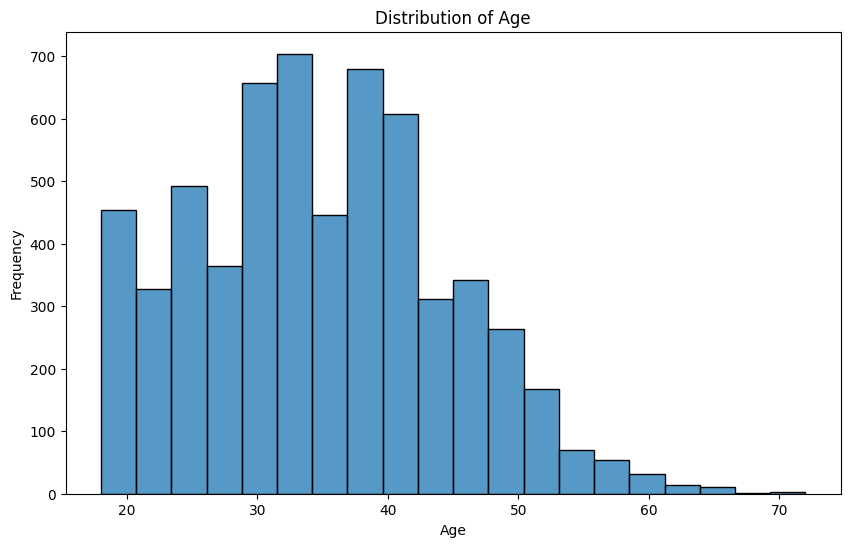

In [8]:
# Customer demographics – age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

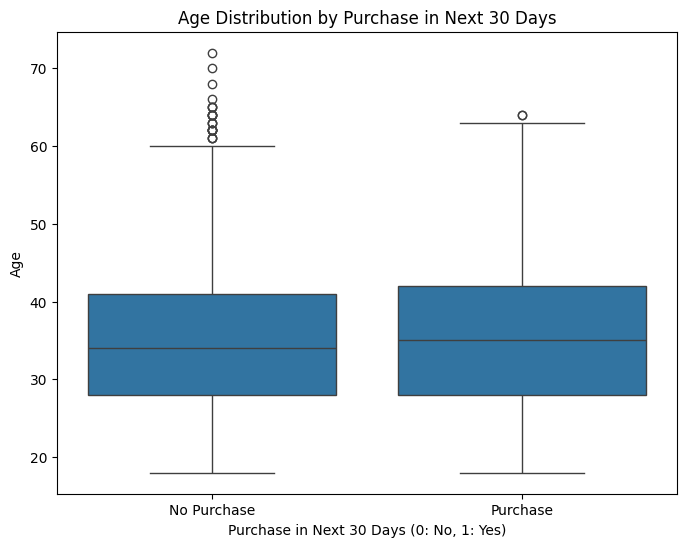

In [9]:
# Age vs purchase outcome
plt.figure(figsize=(8, 6))
sns.boxplot(x='purchase_next_30d', y='age', data=df)
plt.title('Age Distribution by Purchase in Next 30 Days')
plt.xlabel('Purchase in Next 30 Days (0: No, 1: Yes)')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['No Purchase', 'Purchase'])
plt.show()

In [10]:
# Customer mix – gender
print(df['gender'].value_counts(normalize=True))

gender
M    0.500667
F    0.499333
Name: proportion, dtype: float64


In [11]:
# Customer mix – income buckets
print(df['income_bucket'].value_counts(normalize=True))

income_bucket
Mid     0.508167
Low     0.302500
High    0.189333
Name: proportion, dtype: float64


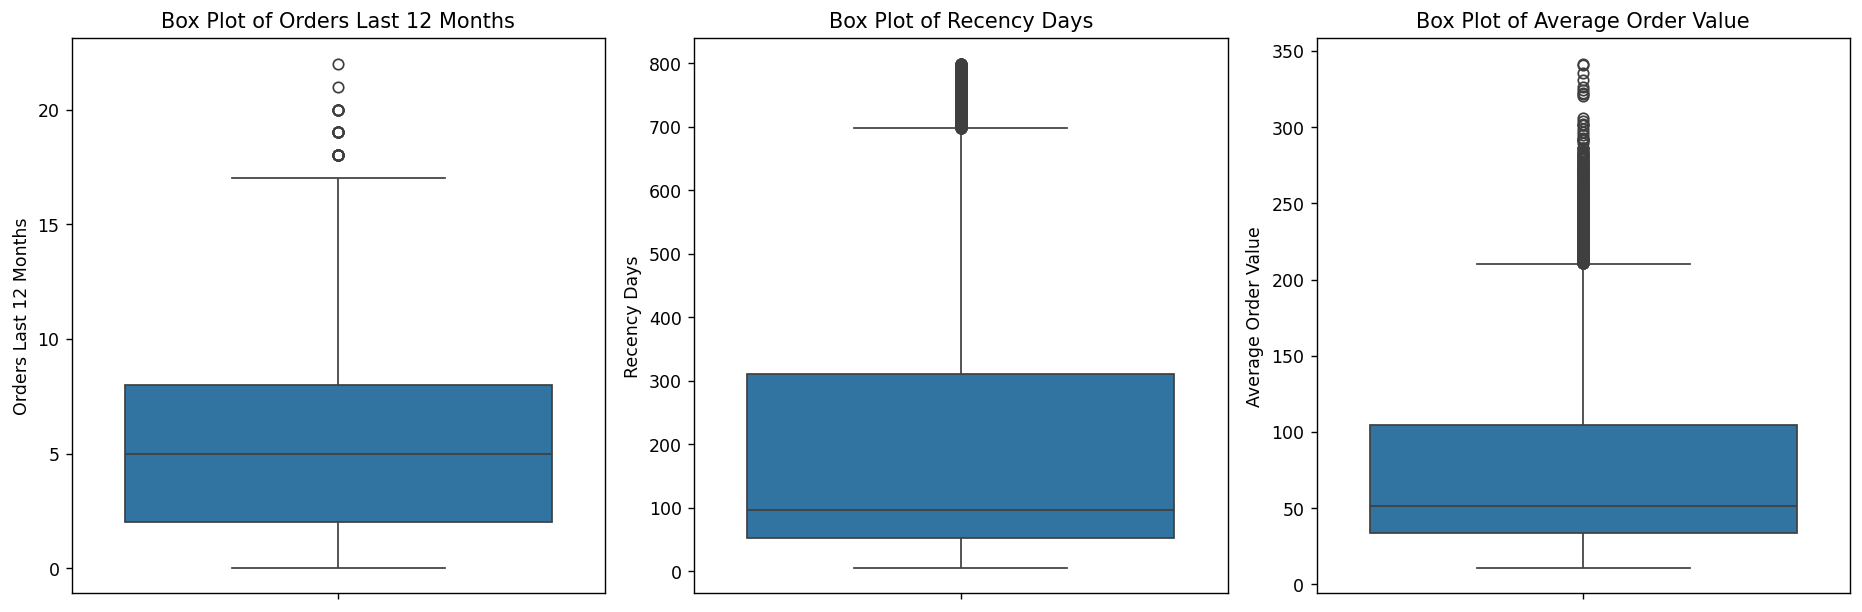

In [12]:
#Boxplots to check for outliers in RFM variables
plt.figure(figsize=(15, 5), dpi=125)

plt.subplot(1, 3, 1)
sns.boxplot(y=df['orders_last_12m'])
plt.title('Box Plot of Orders Last 12 Months')
plt.ylabel('Orders Last 12 Months')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['recency_days'])
plt.title('Box Plot of Recency Days')
plt.ylabel('Recency Days')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['avg_order_value'])
plt.title('Box Plot of Average Order Value')
plt.ylabel('Average Order Value')

plt.tight_layout()
plt.show()

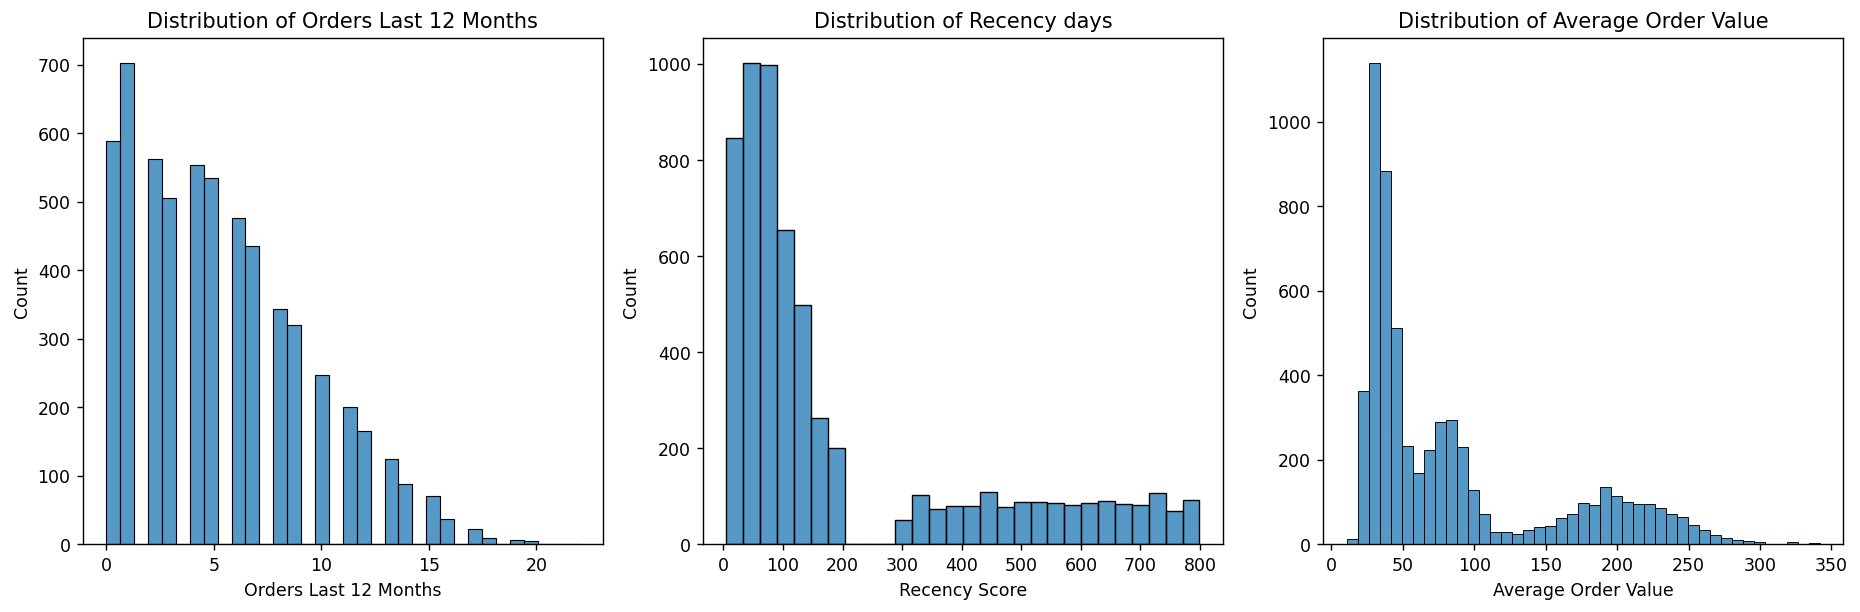

In [13]:
# histograms for discovering skewness
plt.figure(figsize=(15, 5), dpi=125)

plt.subplot(1, 3, 1)
sns.histplot(df['orders_last_12m'])
plt.title('Distribution of Orders Last 12 Months')
plt.xlabel('Orders Last 12 Months')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(df['recency_days'])
plt.title('Distribution of Recency days')
plt.xlabel('Recency Score')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(df['avg_order_value'])
plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

orders_last_12m, recency_days, avg_order_value have long right tails / outliers.

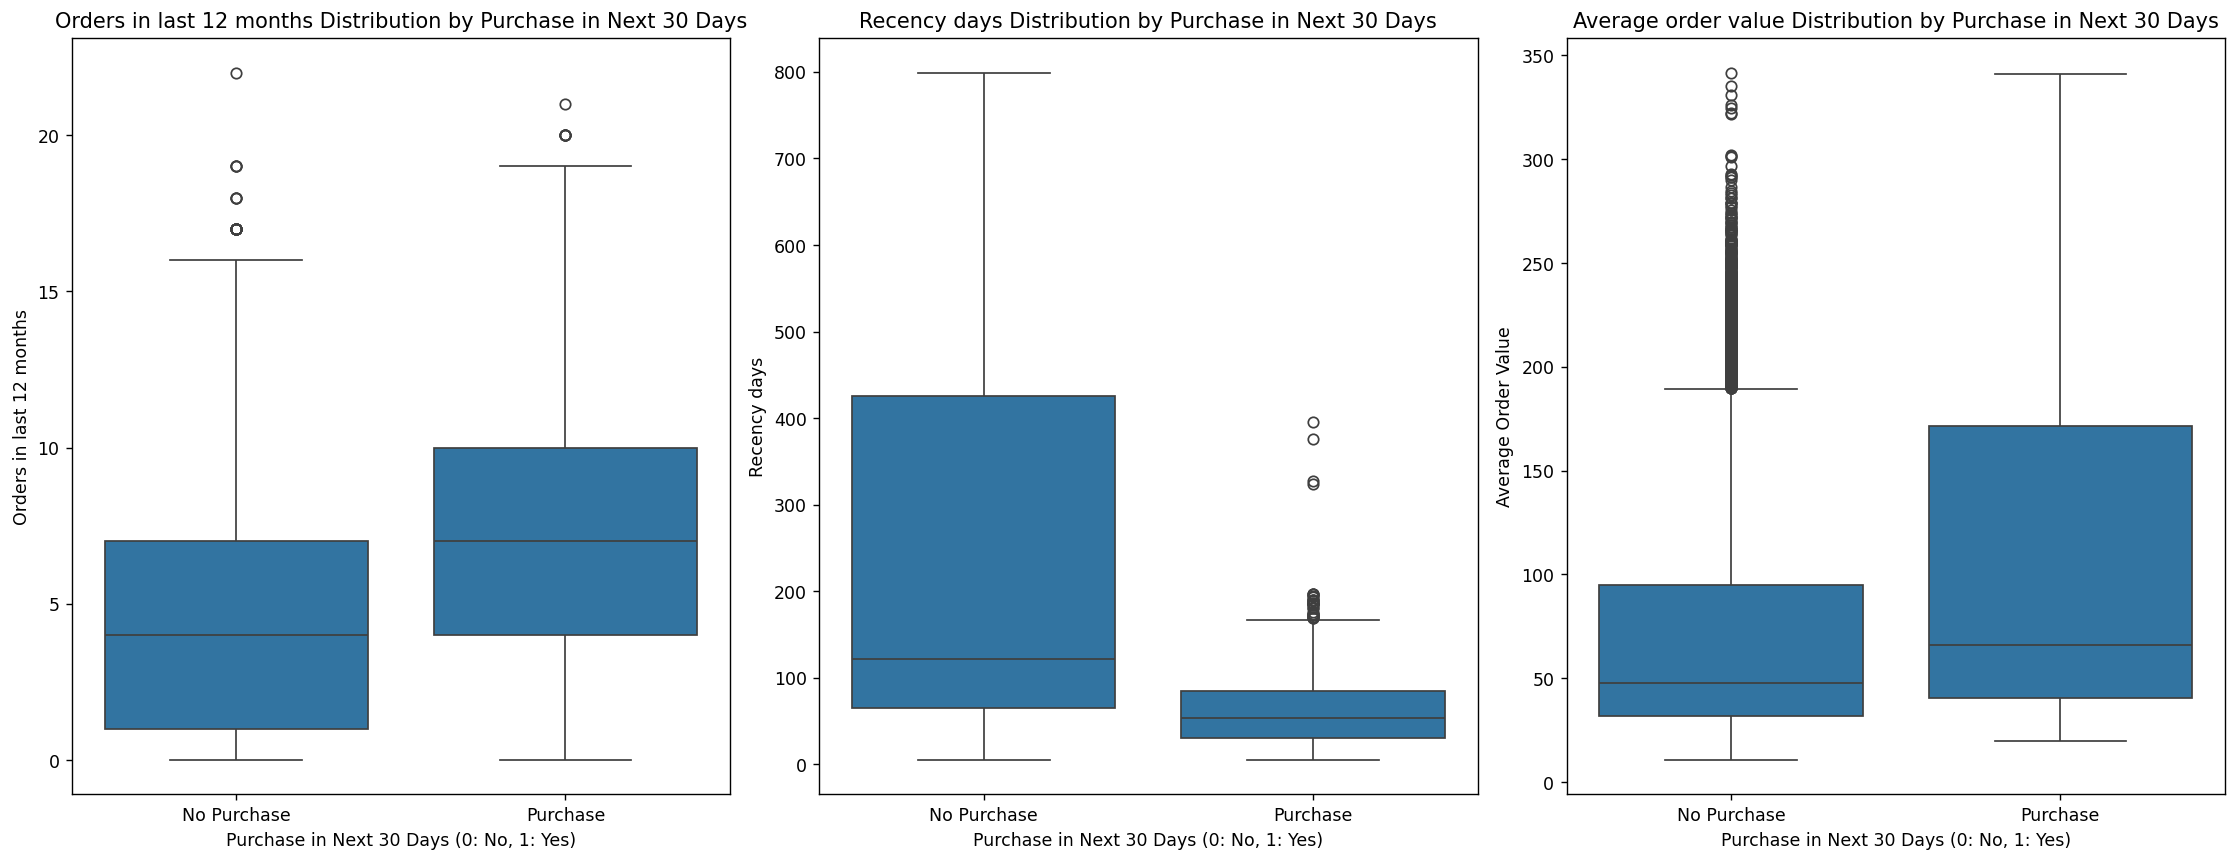

In [14]:
# Behavior and outcome - RFM variables vs purchase
plt.figure(figsize=(18, 7), dpi=125)

plt.subplot(1, 3, 1)
sns.boxplot(x='purchase_next_30d', y='orders_last_12m', data=df)
plt.title('Orders in last 12 months Distribution by Purchase in Next 30 Days')
plt.xlabel('Purchase in Next 30 Days (0: No, 1: Yes)')
plt.ylabel('Orders in last 12 months')
plt.xticks(ticks=[0, 1], labels=['No Purchase', 'Purchase'])

plt.subplot(1, 3, 2)
sns.boxplot(x='purchase_next_30d', y='recency_days', data=df)
plt.title('Recency days Distribution by Purchase in Next 30 Days')
plt.xlabel('Purchase in Next 30 Days (0: No, 1: Yes)')
plt.ylabel('Recency days')
plt.xticks(ticks=[0, 1], labels=['No Purchase', 'Purchase'])

plt.subplot(1, 3, 3)
sns.boxplot(x='purchase_next_30d', y='avg_order_value', data=df)
plt.title('Average order value Distribution by Purchase in Next 30 Days')
plt.xlabel('Purchase in Next 30 Days (0: No, 1: Yes)')
plt.ylabel('Average Order Value')
plt.xticks(ticks=[0, 1], labels=['No Purchase', 'Purchase'])

plt.tight_layout()
plt.show()

Purchasers have more orders, more recent activity (lower recency_days), and slightly higher avg_order_value.

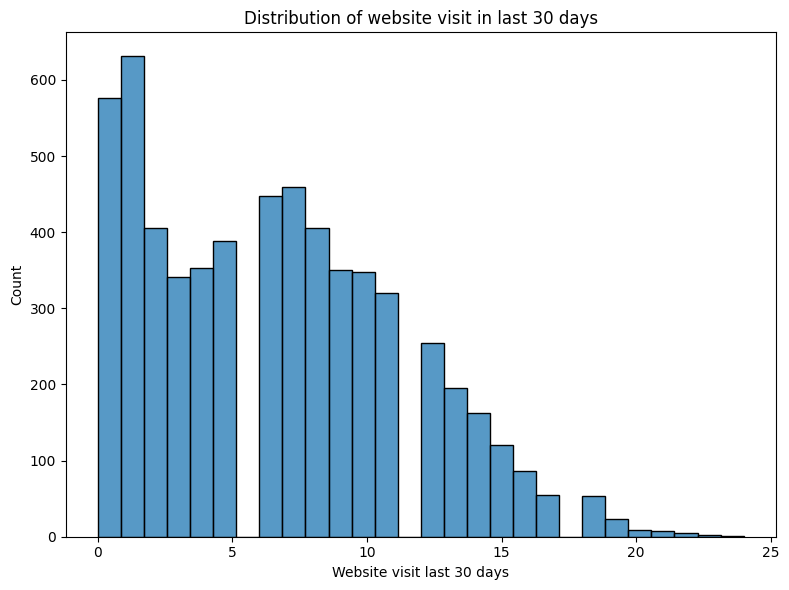

In [15]:
# Engagement distributions – web activity
plt.figure(figsize=(8, 6))
sns.histplot(df['website_visits_30d'])
plt.title('Distribution of website visit in last 30 days')
plt.xlabel('Website visit last 30 days')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

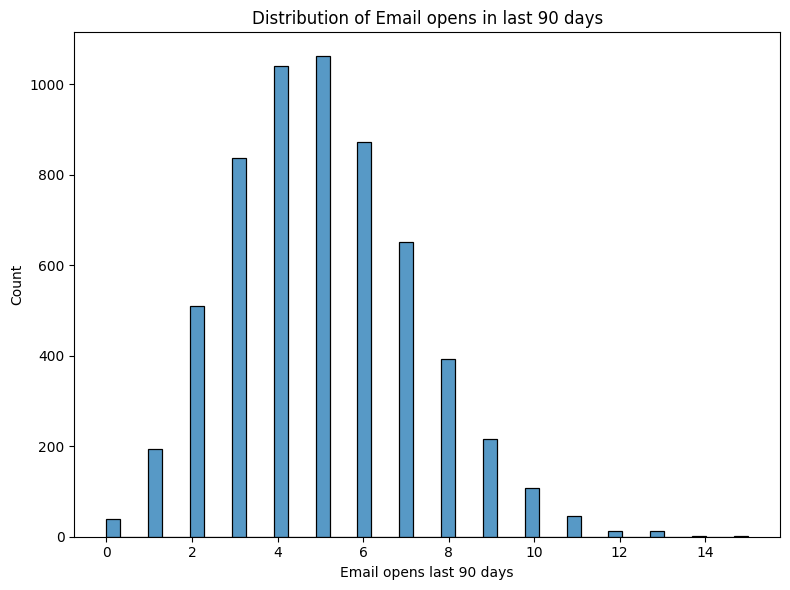

In [16]:
# Engagement distributions – email activity
plt.figure(figsize=(8, 6))
sns.histplot(df['email_opens_90d'])
plt.title('Distribution of Email opens in last 90 days')
plt.xlabel('Email opens last 90 days')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

website_visits_30d and email_opens_90d are skewed count variables but within a moderate range (no extreme zeros-only or huge spikes).

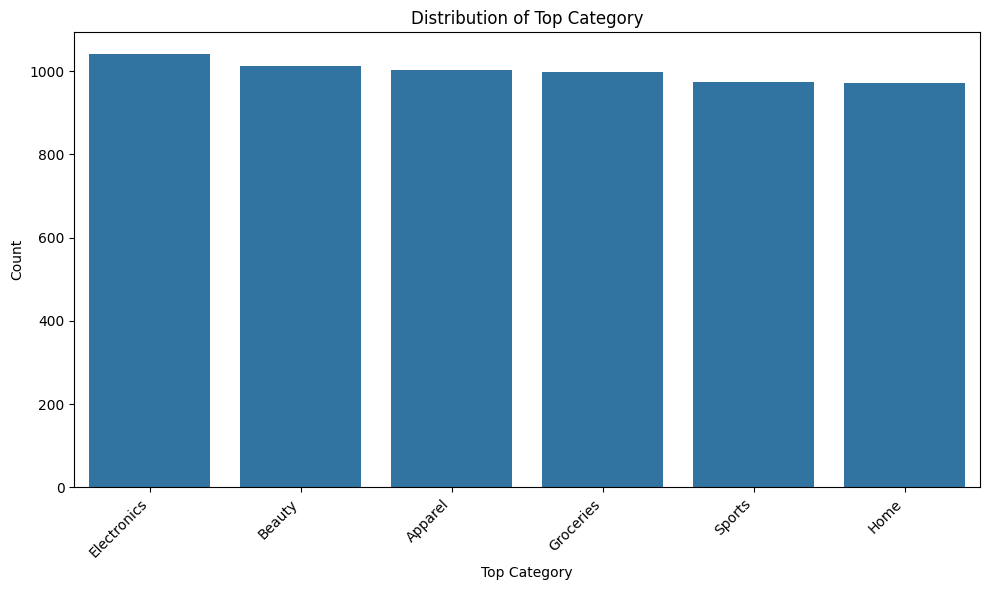

In [17]:
# Product focus – top category mix
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='top_category', order=df['top_category'].value_counts().index)
plt.title('Distribution of Top Category')
plt.xlabel('Top Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_category levels are evenly populated

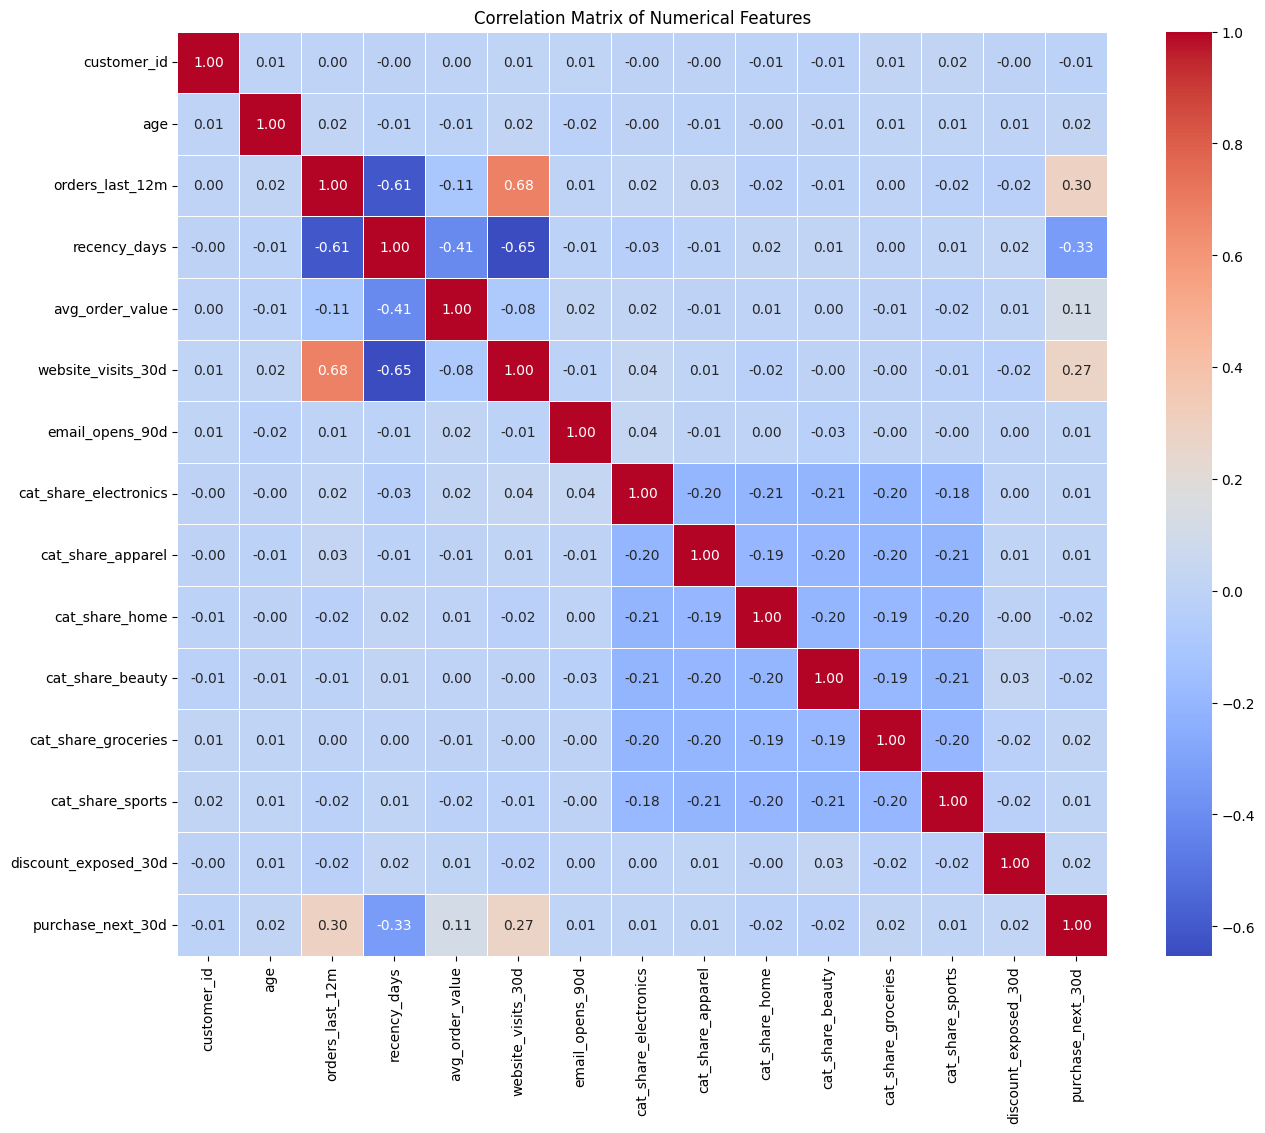

In [18]:
# Correlation structure – numeric features
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Some moderate correlations but no perfect multicollinearity in numeric features.

## 3. Feature Engineering ##

In [19]:
# Create modeling copy and drop non-predictive fields
df_m = df.copy()
df_m = df_m.drop(columns=['customer_id', 'feedback_text'])

### 3.1 Winsorize skewed RFM variables based on EDA

EDA showed long right tails / outliers in orders_last_12m, recency_days, avg_order_value.

Cap extreme values to reduce the impact of outliers without dropping customers.

In [20]:
## Winsorizing skewed RFM variables based on EDA
## Average Order Value: Cap both ends (5% each)
df_m['avg_order_value'] = winsorize(df['avg_order_value'], limits=[0.05, 0.05])

# Recency: Cap ONLY the top (the most inactive)
df_m['recency_days'] = winsorize(df['recency_days'], limits=[0.05, 0.0])

# Frequency: Cap ONLY the top (the extreme power users)
df_m['orders_last_12m'] = winsorize(df['orders_last_12m'], limits=[0.0, 0.01])

### 3.2 Standardize numeric features for regularized models

EDA showed different scales.

Standardize core numeric drivers for Ridge/Lasso; trees are scale-insensitive but can share the same X.

In [21]:
scaler = StandardScaler()

# List of columns to scale
columns_to_scale = [
    'age',
    'orders_last_12m',
    'recency_days',
    'avg_order_value',
    'website_visits_30d',
    'email_opens_90d'
]

# Add 'cat_share_' columns dynamically
for col in df_m.columns:
    if col.startswith('cat_share_'):
        columns_to_scale.append(col)

# Apply scaling to the selected columns in df_m
df_m[columns_to_scale] = scaler.fit_transform(df_m[columns_to_scale])

### 3.3 One-hot encode categorical features

EDA showed well-populated levels for gender, income_bucket, and top_category.

Create dummies (drop_first=True) to avoid dummy trap and keep linear models stable.

In [22]:
# One-hot encode categorical features
df_m = pd.get_dummies(df_m, columns=['gender', 'income_bucket', 'top_category'], drop_first=True)

display(df_m.head())

,age,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,...,discount_exposed_30d,purchase_next_30d,gender_M,income_bucket_Low,income_bucket_Mid,top_category_Beauty,top_category_Electronics,top_category_Groceries,top_category_Home,top_category_Sports
0,0.542117,-0.316870,-0.067866,-0.064018,-0.105195,-1.353108,-0.977619,-0.147206,-0.747292,0.608246,...,0,0,True,False,True,False,False,True,False,False
1,-0.394421,-0.068539,-0.243955,1.284785,-0.105195,-0.002701,0.716939,-0.555296,2.217507,-0.942217,...,0,0,True,False,False,False,False,False,True,False
2,0.854296,-1.061862,1.562087,-0.878837,-1.153994,0.897570,-0.697527,-1.132249,-0.064748,0.761895,...,0,0,False,True,False,False,False,True,False,False
3,-1.122840,0.676453,-0.736101,-0.681943,0.104565,-0.452836,0.261789,-0.309035,0.767102,-0.236826,...,0,0,True,True,False,False,False,False,True,False
4,-0.602541,2.414768,-0.582588,-0.518801,1.363125,-0.002701,-0.683522,-0.597512,0.290743,-1.019041,...,0,0,False,True,False,False,False,False,False,True


## 4. Base Line Models

Train four models (Ridge, Lasso, Random Forest, XGBoost) on the same feature set to compare both predictive metrics and business value (dollar impact).

### 4.1 Ridge

In [23]:
# Use stratified split so the 77/23 class balance is preserved in both train and test sets

X = df_m.drop('purchase_next_30d', axis=1)
y = df_m['purchase_next_30d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nProportion of 'purchase_next_30d' in y_train:\n{y_train.value_counts(normalize=True)}")
print(f"\nProportion of 'purchase_next_30d' in y_test:\n{y_test.value_counts(normalize=True)}")

X_train shape: (4800, 21)
X_test shape: (1200, 21)
y_train shape: (4800,)
y_test shape: (1200,)

Proportion of 'purchase_next_30d' in y_train:
purchase_next_30d
0    0.774167
1    0.225833
Name: proportion, dtype: float64

Proportion of 'purchase_next_30d' in y_test:
purchase_next_30d
0    0.774167
1    0.225833
Name: proportion, dtype: float64


In [24]:
# RidgeClassifier with class_weight='balanced' to handle imbalance
# 5-fold CV on training data (accuracy as a simple baseline check)

# Initialize the Ridge Classifier model
ridge_model = RidgeClassifier(random_state=42, class_weight="balanced")

# Perform 5-fold cross-validation on the training data
cv_scores = cross_val_score(ridge_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation Accuracy scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")

Cross-validation Accuracy scores: [0.57083333 0.57708333 0.56666667 0.56666667 0.57291667]
Mean Accuracy: 0.5708
Standard Deviation of Accuracy: 0.0040


In [25]:
# Fit the Ridge Classifier model to the entire training data
ridge_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = ridge_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Report accuracy, precision, recall, and F1 for the purchase class
print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"Test Set Precision: {precision:.4f}")
print(f"Test Set Recall: {recall:.4f}")
print(f"Test Set F1-Score: {f1:.4f}")

Test Set Accuracy: 0.5833
Test Set Precision: 0.3463
Test Set Recall: 0.9520
Test Set F1-Score: 0.5079


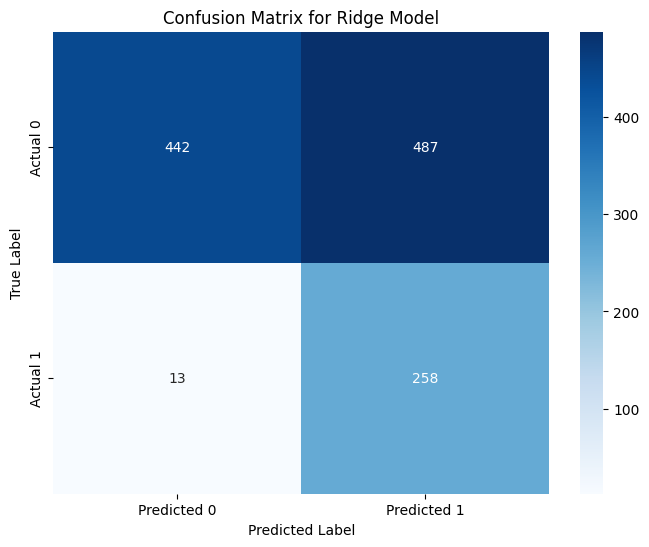

In [26]:
# Calculate the confusion matrix for Ridge
cm_ridge = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ridge, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Ridge Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [27]:
# Translate TP/FP/TN/FN counts into total dollar value
# using the assignment’s payoff structure

# Define dollar values for each quadrant (re-using the same values)
value_tp = 15  # True Positive
value_fp = -5  # False Positive
value_tn = 0   # True Negative
value_fn = -10 # False Negative

# Extract counts from the Ridge confusion matrix (cm_ridge)
# cm_ridge is structured as: [[TN, FP], [FN, TP]]
TN_ridge, FP_ridge, FN_ridge, TP_ridge = cm_ridge.ravel()

# Calculate the total dollar value for the Ridge model
dollar_value_ridge = (TP_ridge * value_tp) + \
                     (FP_ridge * value_fp) + \
                     (TN_ridge * value_tn) + \
                     (FN_ridge * value_fn)

print(f"Ridge Model - True Positives (TP) $ value: {TP_ridge * value_tp}")
print(f"Ridge Model - False Positives (FP) $ value: {FP_ridge * value_fp}")
print(f"Ridge Model - True Negatives (TN) $ value: {TN_ridge * value_tn}")
print(f"Ridge Model - False Negatives (FN) $ value: {FN_ridge * value_fn}")
print(f"\nTotal Dollar Value for Ridge Model $ value: ${dollar_value_ridge}")

Ridge Model - True Positives (TP) $ value: 3870
Ridge Model - False Positives (FP) $ value: -2435
Ridge Model - True Negatives (TN) $ value: 0
Ridge Model - False Negatives (FN) $ value: -130

Total Dollar Value for Ridge Model $ value: $1305


### 4.2 Lasso

In [28]:
# L1 penalty performs variable selection (some coefficients shrink to ~0).
# Keep class_weight='balanced' and same CV setup as Ridge.

# Initialize the Lasso Classifier model (using LogisticRegression with L1 penalty)
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, class_weight="balanced")

# Perform 5-fold cross-validation on the training data
cv_scores_lasso = cross_val_score(lasso_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Lasso Cross-validation Accuracy scores: {cv_scores_lasso}")
print(f"Lasso Mean Accuracy: {np.mean(cv_scores_lasso):.4f}")
print(f"Lasso Standard Deviation of Accuracy: {np.std(cv_scores_lasso):.4f}")



Lasso Cross-validation Accuracy scores: [0.63541667 0.63333333 0.6375     0.63958333 0.63229167]
Lasso Mean Accuracy: 0.6356
Lasso Standard Deviation of Accuracy: 0.0027


In [29]:
# Fit the Lasso Classifier model to the entire training data
lasso_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lasso = lasso_model.predict(X_test)

# Calculate evaluation metrics for Lasso
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
precision_lasso = precision_score(y_test, y_pred_lasso)
recall_lasso = recall_score(y_test, y_pred_lasso)
f1_lasso = f1_score(y_test, y_pred_lasso)

# Report accuracy, precision, recall, and F1 for the purchase class
print(f"\nLasso Test Set Accuracy: {accuracy_lasso:.4f}")
print(f"Lasso Test Set Precision: {precision_lasso:.4f}")
print(f"Lasso Test Set Recall: {recall_lasso:.4f}")
print(f"Lasso Test Set F1-Score: {f1_lasso:.4f}")


Lasso Test Set Accuracy: 0.6350
Lasso Test Set Precision: 0.3705
Lasso Test Set Recall: 0.8819
Lasso Test Set F1-Score: 0.5218


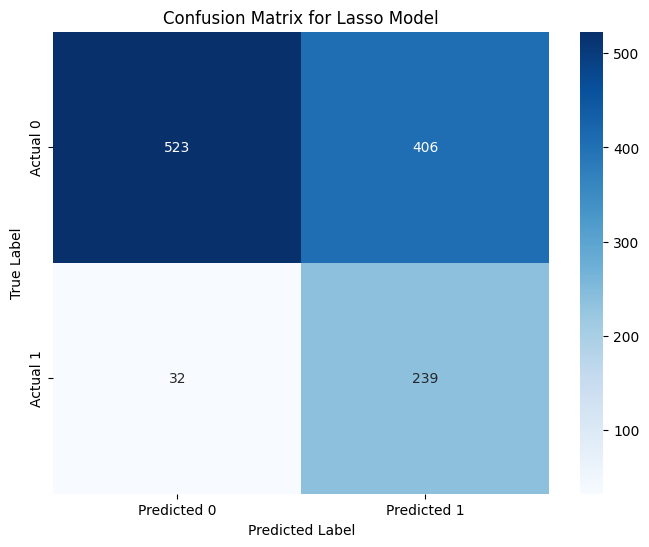

In [30]:
# Calculate the confusion matrix for Lasso
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lasso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Lasso Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [31]:
# Translate TP/FP/TN/FN counts into total dollar value
# using the assignment’s payoff structure

# Extract counts from the Lasso confusion matrix (cm_lasso)
# cm_lasso is structured as: [[TN, FP], [FN, TP]]
TN_lasso, FP_lasso, FN_lasso, TP_lasso = cm_lasso.ravel()

# Calculate the total dollar value for the Lasso model
dollar_value_lasso = (TP_lasso * value_tp) + \
                     (FP_lasso * value_fp) + \
                     (TN_lasso * value_tn) + \
                     (FN_lasso * value_fn)

print(f"Lasso Model - True Positives (TP) $ value: {TP_lasso * value_tp}")
print(f"Lasso Model - False Positives (FP) $ value: {FP_lasso * value_fp}")
print(f"Lasso Model - True Negatives (TN) $ value: {TN_lasso * value_tn}")
print(f"Lasso Model - False Negatives (FN) $ value: {FN_lasso * value_fn}")
print(f"\nTotal Dollar Value for Lasso Model $ value: ${dollar_value_lasso}")

Lasso Model - True Positives (TP) $ value: 3585
Lasso Model - False Positives (FP) $ value: -2030
Lasso Model - True Negatives (TN) $ value: 0
Lasso Model - False Negatives (FN) $ value: -320

Total Dollar Value for Lasso Model $ value: $1235


### 4.3 Random Forest

In [32]:
# Tree-based model that can capture non-linearities and interactions
# Use class_weight='balanced' and 5-fold CV for a quick accuracy check

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")

# Perform 5-fold cross-validation on the training data
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Random Forest Cross-validation Accuracy scores: {cv_scores_rf}")
print(f"Random Forest Mean Accuracy: {np.mean(cv_scores_rf):.4f}")
print(f"Random Forest Standard Deviation of Accuracy: {np.std(cv_scores_rf):.4f}")

Random Forest Cross-validation Accuracy scores: [0.78020833 0.778125   0.775      0.77291667 0.76979167]
Random Forest Mean Accuracy: 0.7752
Random Forest Standard Deviation of Accuracy: 0.0037


In [33]:
# Fit the Random Forest Classifier model to the entire training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Report accuracy, precision, recall, and F1 for the purchase class
print(f"\nRandom Forest Test Set Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Test Set Precision: {precision_rf:.4f}")
print(f"Random Forest Test Set Recall: {recall_rf:.4f}")
print(f"Random Forest Test Set F1-Score: {f1_rf:.4f}")

# Note that accuracy can be high even if recall on purchasers is low.


Random Forest Test Set Accuracy: 0.7758
Random Forest Test Set Precision: 0.5238
Random Forest Test Set Recall: 0.0812
Random Forest Test Set F1-Score: 0.1406


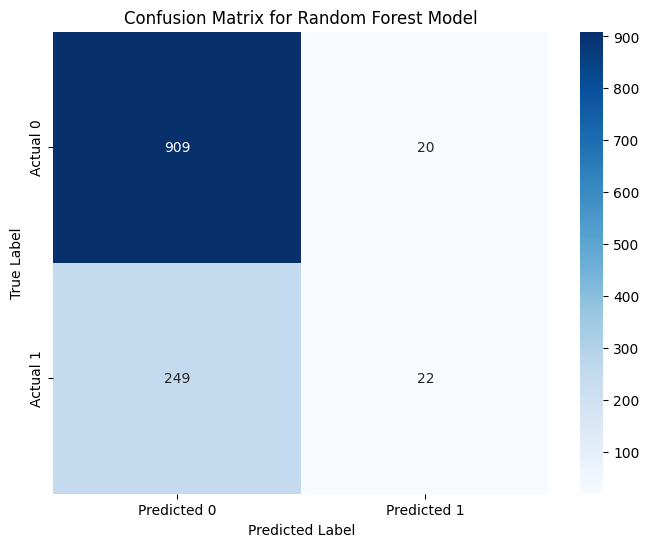

In [34]:
# Calculate the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [35]:
# Translate TP/FP/TN/FN counts into total dollar value
# using the assignment’s payoff structure

# Extract counts from the Random Forest confusion matrix (cm_rf)
# cm_rf is structured as: [[TN, FP], [FN, TP]]
TN_rf, FP_rf, FN_rf, TP_rf = cm_rf.ravel()

# Calculate the total dollar value for the Random Forest model
dollar_value_rf = (TP_rf * value_tp) + \
                     (FP_rf * value_fp) + \
                     (TN_rf * value_tn) + \
                     (FN_rf * value_fn)

print(f"Random Forest Model - True Positives (TP) $ value: {TP_rf * value_tp}")
print(f"Random Forest Model - False Positives (FP) $ value: {FP_rf * value_fp}")
print(f"Random Forest Model - True Negatives (TN) $ value: {TN_rf * value_tn}")
print(f"Random Forest Model - False Negatives (FN) $ value: {FN_rf * value_fn}")
print(f"\nTotal Dollar Value for Random Forest Model $ value: ${dollar_value_rf}")

Random Forest Model - True Positives (TP) $ value: 330
Random Forest Model - False Positives (FP) $ value: -100
Random Forest Model - True Negatives (TN) $ value: 0
Random Forest Model - False Negatives (FN) $ value: -2490

Total Dollar Value for Random Forest Model $ value: $-2260


### 4.4 XGBoost

In [36]:
# Gradient boosting model with explicit class imbalance handling via scale_pos_weight.
# Hyperparameters kept simple (max_depth=3, n_estimators=200, subsample/colsample < 1).

# Calculate scale_pos_weight for handling class imbalance
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize the XGBoost Classifier model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42,
    scale_pos_weight=scale_pos_weight_value,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8
)

# Perform 5-fold cross-validation on the training data
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"XGBoost Cross-validation Accuracy scores: {cv_scores_xgb}")
print(f"XGBoost Mean Accuracy: {np.mean(cv_scores_xgb):.4f}")
print(f"XGBoost Standard Deviation of Accuracy: {np.std(cv_scores_xgb):.4f}")

Calculated scale_pos_weight: 3.43


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:00:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:00:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:00:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:00:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Cross-validation Accuracy scores: [0.69583333 0.67604167 0.69270833 0.68125    0.66354167]
XGBoost Mean Accuracy: 0.6819
XGBoost Standard Deviation of Accuracy: 0.0117


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:00:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
# Fit the XGBoost Classifier model to the entire training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics for XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Report accuracy, precision, recall, and F1 for the purchase class
print(f"\nXGBoost Test Set Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Test Set Precision: {precision_xgb:.4f}")
print(f"XGBoost Test Set Recall: {recall_xgb:.4f}")
print(f"XGBoost Test Set F1-Score: {f1_xgb:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:00:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Test Set Accuracy: 0.6875
XGBoost Test Set Precision: 0.3750
XGBoost Test Set Recall: 0.5756
XGBoost Test Set F1-Score: 0.4541


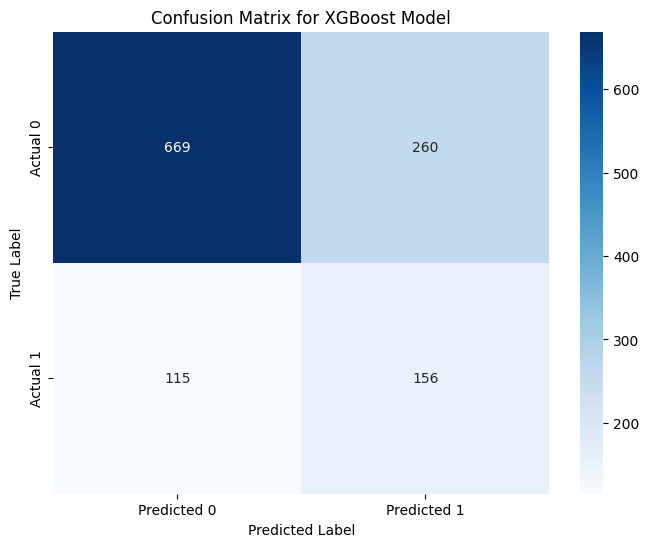

In [38]:
# Calculate the confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for XGBoost Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [39]:
# Translate TP/FP/TN/FN counts into total dollar value
# using the assignment’s payoff structure

# Extract counts from the XGBoost confusion matrix (cm_xgb)
# cm_xgb is structured as: [[TN, FP], [FN, TP]]
TN_xgb, FP_xgb, FN_xgb, TP_xgb = cm_xgb.ravel()

# Calculate the total dollar value for the XGBoost model
dollar_value_xgb = (TP_xgb * value_tp) + \
                     (FP_xgb * value_fp) + \
                     (TN_xgb * value_tn) + \
                     (FN_xgb * value_fn)

print(f"XGBoost Model - True Positives (TP) $ value: {TP_xgb * value_tp}")
print(f"XGBoost Model - False Positives (FP) $ value: {FP_xgb * value_fp}")
print(f"XGBoost Model - True Negatives (TN) $ value: {TN_xgb * value_tn}")
print(f"XGBoost Model - False Negatives (FN) $ value: {FN_xgb * value_fn}")
print(f"\nTotal Dollar Value for XGBoost Model $ value: ${dollar_value_xgb}")

XGBoost Model - True Positives (TP) $ value: 2340
XGBoost Model - False Positives (FP) $ value: -1300
XGBoost Model - True Negatives (TN) $ value: 0
XGBoost Model - False Negatives (FN) $ value: -1150

Total Dollar Value for XGBoost Model $ value: $-110


Regularized linear models (Ridge and Lasso with class weights) handle the class imbalance better than the initial tree models, giving reasonable recall and positive dollar value, while Random Forest and XGBoost baselines show that high accuracy alone does not guarantee business value.

## 5. Tuning the models
Optimize decision thresholds using business dollar value instead of relying on the default 0.5 cutoff.

In [40]:
# Helper: compute total dollar value from a confusion matrix
# using the assignment's TP/FP/TN/FN payoff structure.

def dollar_value_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()
    return TP*value_tp + FP*value_fp + TN*value_tn + FN*value_fn

### 5.1 Ridge (Optimized)

In [41]:
# Sweep thresholds over Ridge decision scores to find
# the profit-maximizing cutoff on the test set.

thresholds_ridge = np.linspace(-1.0, 1.0, 41)

In [42]:
# Search over decision_function thresholds and keep the
# confusion matrix with the highest dollar value.

# Get decision function scores for the Ridge model
y_scores_ridge = ridge_model.decision_function(X_test)

# Re-using the dollar_value_from_cm function and thresholds array defined previously

best_thr_ridge = None
best_value_ridge = -np.inf
best_cm_ridge = None

for thr in thresholds_ridge:
    # For RidgeClassifier, use decision_function as score for thresholding
    y_pred_thr_ridge = (y_scores_ridge >= thr).astype(int)
    cm_thr_ridge = confusion_matrix(y_test, y_pred_thr_ridge)
    val_thr_ridge = dollar_value_from_cm(cm_thr_ridge)
    if val_thr_ridge > best_value_ridge:
        best_value_ridge = val_thr_ridge
        best_thr_ridge = thr
        best_cm_ridge = cm_thr_ridge

print("Best threshold for Ridge Model:", best_thr_ridge)
print("Best dollar value for Ridge Model:", best_value_ridge)
print("Best confusion matrix at this threshold:\n", best_cm_ridge)

Best threshold for Ridge Model: 0.0
Best dollar value for Ridge Model: 1305
Best confusion matrix at this threshold:
 [[442 487]
 [ 13 258]]


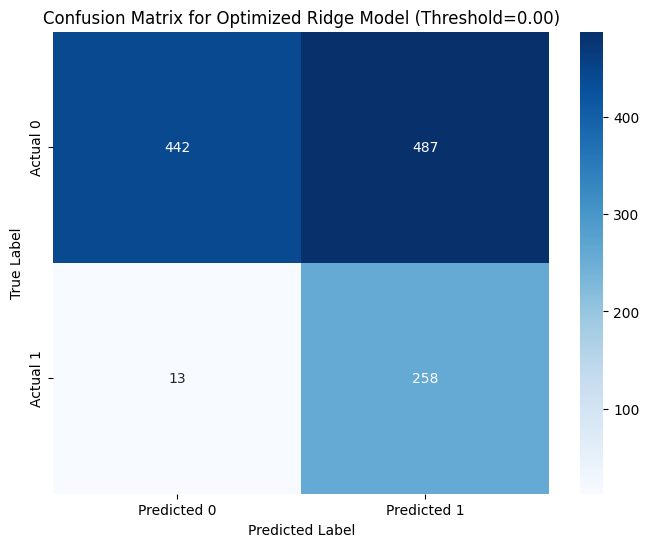

In [43]:
# Plot the confusion matrix for the optimized Ridge model
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm_ridge, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Optimized Ridge Model (Threshold={best_thr_ridge:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.2 Lasso (Optimized)

In [44]:
# Use predicted probabilities and search thresholds in [0.1, 0.9]
# to maximize dollar value for the L1 logistic model.

thresholds = np.linspace(0.1, 0.9, 17)  # 0.10, 0.15, ..., 0.90

In [45]:
# For each threshold, convert probabilities to 0/1, compute
# confusion matrix and dollar value, and keep the best.

# Get predicted probabilities for class 1 from the fitted Lasso model
y_proba_lasso = lasso_model.predict_proba(X_test)[:, 1]

# Re-using the dollar_value_from_cm function and thresholds array defined previously

best_thr_lasso = None
best_value_lasso = -np.inf
best_cm_lasso = None

for thr in thresholds:
    y_pred_thr_lasso = (y_proba_lasso >= thr).astype(int)
    cm_thr_lasso = confusion_matrix(y_test, y_pred_thr_lasso)
    val_thr_lasso = dollar_value_from_cm(cm_thr_lasso)
    if val_thr_lasso > best_value_lasso:
        best_value_lasso = val_thr_lasso
        best_thr_lasso = thr
        best_cm_lasso = cm_thr_lasso

print("Best threshold for Lasso Model:", best_thr_lasso)
print("Best dollar value for Lasso Model:", best_value_lasso)
print("Best confusion matrix at this threshold:\n", best_cm_lasso)

Best threshold for Lasso Model: 0.45000000000000007
Best dollar value for Lasso Model: 1370
Best confusion matrix at this threshold:
 [[480 449]
 [ 18 253]]


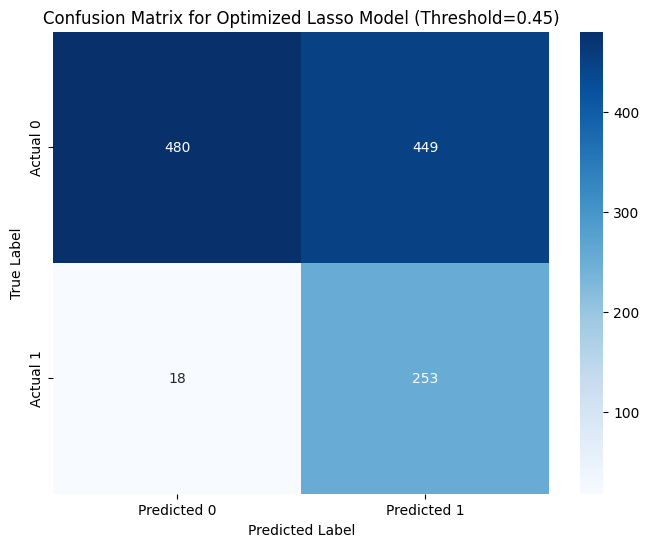

In [46]:
# Plot the confusion matrix for the optimized Lasso model
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm_lasso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Optimized Lasso Model (Threshold={best_thr_lasso:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.3 Random Forest (Optimized)

In [47]:
# Repeat the same probability-based threshold sweep for RF.
# Aim: trade some TN for more TP to improve profit.

# Get predicted probabilities for class 1 from the fitted Random Forest model
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Re-using the dollar_value_from_cm function and thresholds array defined previously

best_thr_rf = None
best_value_rf = -np.inf
best_cm_rf = None

for thr in thresholds:
    y_pred_thr_rf = (y_proba_rf >= thr).astype(int)
    cm_thr_rf = confusion_matrix(y_test, y_pred_thr_rf)
    val_thr_rf = dollar_value_from_cm(cm_thr_rf)
    if val_thr_rf > best_value_rf:
        best_value_rf = val_thr_rf
        best_thr_rf = thr
        best_cm_rf = cm_thr_rf

print("Best threshold for Random Forest:", best_thr_rf)
print("Best dollar value for Random Forest:", best_value_rf)
print("Best confusion matrix at this threshold:\n", best_cm_rf)

Best threshold for Random Forest: 0.2
Best dollar value for Random Forest: 1230
Best confusion matrix at this threshold:
 [[487 442]
 [ 25 246]]


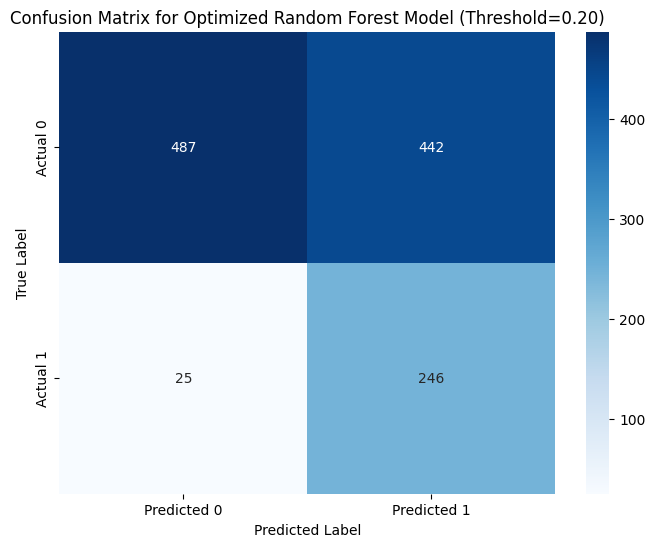

In [48]:
# Plot the confusion matrix for the optimized Random Forest model
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Optimized Random Forest Model (Threshold={best_thr_rf:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.4 XGBoost (Optimized)

In [49]:
# Sweep probability thresholds for XGBoost and select the
# cutoff that maximizes total dollar value.

# Get predicted probabilities for class 1 from the fitted XGBoost model
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

best_thr = None
best_value = -np.inf
best_cm = None

for thr in thresholds:
    y_pred_thr = (y_proba_xgb >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_pred_thr)
    val_thr = dollar_value_from_cm(cm_thr)
    if val_thr > best_value:
        best_value = val_thr
        best_thr = thr
        best_cm = cm_thr

print("Best threshold for XGBoost:", best_thr)
print("Best dollar value for XGBoost:", best_value)
print("Best confusion matrix at this threshold:\n", best_cm)

Best threshold for XGBoost: 0.15000000000000002
Best dollar value for XGBoost: 1340
Best confusion matrix at this threshold:
 [[419 510]
 [  7 264]]


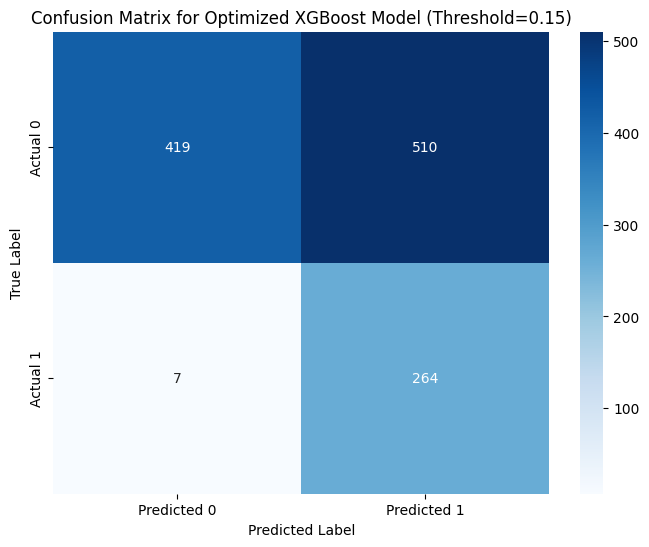

In [50]:
# Plot the confusion matrix for the optimized XGBoost model
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Optimized XGBoost Model (Threshold={best_thr:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

After optimizing decision thresholds using the business dollar value (instead of default 0.5), Lasso and XGBoost improve profit substantially, with optimized Lasso achieving the highest total dollar value, confirming that threshold choice is as important as the underlying model for this problem.

## 6 Model Comparison

Compare all models (base vs optimized) on total dollar value to identify the best business choice.

In [51]:
model_comparison_data = {
    'Model': ['Ridge (Non-Optimized)', 'Ridge (Optimized)',
              'Lasso (Non-Optimized)', 'Lasso (Optimized)',
              'Random Forest (Non-Optimized)', 'Random Forest (Optimized)',
              'XGBoost (Non-Optimized)', 'XGBoost (Optimized)'],
    'Total Dollar Value': [dollar_value_ridge, best_value_ridge,
                           dollar_value_lasso, best_value_lasso,
                           dollar_value_rf, best_value_rf,
                           dollar_value_xgb, best_value]
}

df_comparison = pd.DataFrame(model_comparison_data)
df_comparison_sorted = df_comparison.sort_values(by='Total Dollar Value', ascending=False).reset_index(drop=True)

display(df_comparison_sorted)

,Model,Total Dollar Value
0,Lasso (Optimized),1370
1,XGBoost (Optimized),1340
2,Ridge (Optimized),1305
3,Ridge (Non-Optimized),1305
4,Lasso (Non-Optimized),1235
5,Random Forest (Optimized),1230
6,XGBoost (Non-Optimized),-110
7,Random Forest (Non-Optimized),-2260


/tmp/ipykernel_1130/3670730896.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Total Dollar Value', data=df_comparison_sorted, palette='viridis')


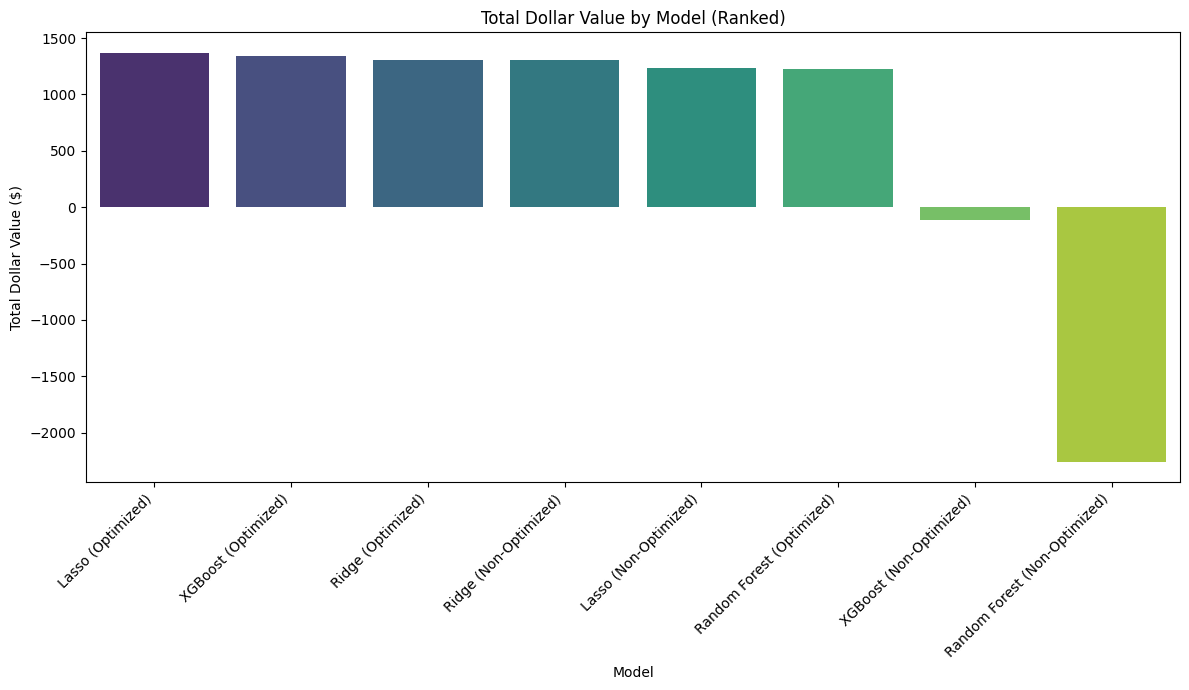

In [59]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Total Dollar Value', data=df_comparison_sorted, palette='viridis')
plt.title('Total Dollar Value by Model (Ranked)')
plt.xlabel('Model')
plt.ylabel('Total Dollar Value ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Lasso gives the best dollar value among all the models**

In [52]:
# Compare standard classification metrics across all models
# to complement the dollar-value comparison and highlight
# trade-offs between accuracy, recall, and profit.

# --- Calculate metrics for Optimized Ridge Model from best_cm_ridge ---
TN_ridge_opt, FP_ridge_opt, FN_ridge_opt, TP_ridge_opt = best_cm_ridge.ravel()
total_ridge_opt = TN_ridge_opt + FP_ridge_opt + FN_ridge_opt + TP_ridge_opt
acc_ridge_opt = (TP_ridge_opt + TN_ridge_opt) / total_ridge_opt
prec_ridge_opt = TP_ridge_opt / (TP_ridge_opt + FP_ridge_opt) if (TP_ridge_opt + FP_ridge_opt) > 0 else 0
rec_ridge_opt = TP_ridge_opt / (TP_ridge_opt + FN_ridge_opt) if (TP_ridge_opt + FN_ridge_opt) > 0 else 0
f1_ridge_opt = (2 * prec_ridge_opt * rec_ridge_opt) / (prec_ridge_opt + rec_ridge_opt) if (prec_ridge_opt + rec_ridge_opt) > 0 else 0

# --- Calculate metrics for Optimized Lasso Model from best_cm_lasso ---
TN_lasso_opt, FP_lasso_opt, FN_lasso_opt, TP_lasso_opt = best_cm_lasso.ravel()
total_lasso_opt = TN_lasso_opt + FP_lasso_opt + FN_lasso_opt + TP_lasso_opt
acc_lasso_opt = (TP_lasso_opt + TN_lasso_opt) / total_lasso_opt
prec_lasso_opt = TP_lasso_opt / (TP_lasso_opt + FP_lasso_opt) if (TP_lasso_opt + FP_lasso_opt) > 0 else 0
rec_lasso_opt = TP_lasso_opt / (TP_lasso_opt + FN_lasso_opt) if (TP_lasso_opt + FN_lasso_opt) > 0 else 0
f1_lasso_opt = (2 * prec_lasso_opt * rec_lasso_opt) / (prec_lasso_opt + rec_lasso_opt) if (prec_lasso_opt + rec_lasso_opt) > 0 else 0

# --- Calculate metrics for Optimized Random Forest Model from best_cm_rf ---
TN_rf_opt, FP_rf_opt, FN_rf_opt, TP_rf_opt = best_cm_rf.ravel()
total_rf_opt = TN_rf_opt + FP_rf_opt + FN_rf_opt + TP_rf_opt
acc_rf_opt = (TP_rf_opt + TN_rf_opt) / total_rf_opt
prec_rf_opt = TP_rf_opt / (TP_rf_opt + FP_rf_opt) if (TP_rf_opt + FP_rf_opt) > 0 else 0
rec_rf_opt = TP_rf_opt / (TP_rf_opt + FN_rf_opt) if (TP_rf_opt + FN_rf_opt) > 0 else 0
f1_rf_opt = (2 * prec_rf_opt * rec_rf_opt) / (prec_rf_opt + rec_rf_opt) if (prec_rf_opt + rec_rf_opt) > 0 else 0

# --- Calculate metrics for Optimized XGBoost Model from best_cm ---
TN_xgb_opt, FP_xgb_opt, FN_xgb_opt, TP_xgb_opt = best_cm.ravel()
total_xgb_opt = TN_xgb_opt + FP_xgb_opt + FN_xgb_opt + TP_xgb_opt
acc_xgb_opt = (TP_xgb_opt + TN_xgb_opt) / total_xgb_opt
prec_xgb_opt = TP_xgb_opt / (TP_xgb_opt + FP_xgb_opt) if (TP_xgb_opt + FP_xgb_opt) > 0 else 0
rec_xgb_opt = TP_xgb_opt / (TP_xgb_opt + FN_xgb_opt) if (TP_xgb_opt + FN_xgb_opt) > 0 else 0
f1_xgb_opt = (2 * prec_xgb_opt * rec_xgb_opt) / (prec_xgb_opt + rec_xgb_opt) if (prec_xgb_opt + rec_xgb_opt) > 0 else 0

# --- Create the comparison DataFrame ---
metrics_comparison_data = {
    'Model': [
        'Ridge (Non-Optimized)', 'Ridge (Optimized)',
        'Lasso (Non-Optimized)', 'Lasso (Optimized)',
        'Random Forest (Non-Optimized)', 'Random Forest (Optimized)',
        'XGBoost (Non-Optimized)', 'XGBoost (Optimized)'
    ],
    'Accuracy': [
        accuracy, acc_ridge_opt,
        accuracy_lasso, acc_lasso_opt,
        accuracy_rf, acc_rf_opt,
        accuracy_xgb, acc_xgb_opt
    ],
    'Precision': [
        precision, prec_ridge_opt,
        precision_lasso, prec_lasso_opt,
        precision_rf, prec_rf_opt,
        precision_xgb, prec_xgb_opt
    ],
    'Recall': [
        recall, rec_ridge_opt,
        recall_lasso, rec_lasso_opt,
        recall_rf, rec_rf_opt,
        recall_xgb, rec_xgb_opt
    ],
    'F1-Score': [
        f1, f1_ridge_opt,
        f1_lasso, f1_lasso_opt,
        f1_rf, f1_rf_opt,
        f1_xgb, f1_xgb_opt
    ]
}

df_metrics_comparison = pd.DataFrame(metrics_comparison_data)
display(df_metrics_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Ridge (Non-Optimized),0.5833,0.3463,0.9520,0.5079
1,Ridge (Optimized),0.5833,0.3463,0.9520,0.5079
2,Lasso (Non-Optimized),0.6350,0.3705,0.8819,0.5218
3,Lasso (Optimized),0.6108,0.3604,0.9336,0.5200
4,Random Forest (Non-Optimized),0.7758,0.5238,0.0812,0.1406
5,Random Forest (Optimized),0.6108,0.3576,0.9077,0.5130
6,XGBoost (Non-Optimized),0.6875,0.3750,0.5756,0.4541
7,XGBoost (Optimized),0.5692,0.3411,0.9742,0.5053


Comparing all eight model variants shows that optimized Lasso is the best business model (highest dollar value), followed closely by optimized XGBoost and optimized Ridge, while both non‑optimized trees can even destroy value, reinforcing the need for cost‑aware tuning rather than relying on raw accuracy.

## 7. Feature Importance

Use Lasso (best dollar-value model) coefficients to identify which features drive purchase propensity up or down.

In [53]:
# Build a ranked table of features by absolute coefficient size
# (larger |coef| = stronger impact on purchase likelihood).

feature_names = X_train.columns
coefs = lasso_model.coef_.ravel()  # shape (n_features,)

lasso_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

lasso_importance.head(20)

,feature,coef,abs_coef
2,recency_days,-2.524618,2.524618
1,orders_last_12m,0.255358,0.255358
19,top_category_Home,-0.219367,0.219367
17,top_category_Electronics,0.207273,0.207273
3,avg_order_value,0.169266,0.169266
18,top_category_Groceries,0.146453,0.146453
12,discount_exposed_30d,0.143885,0.143885
4,website_visits_30d,0.135223,0.135223
6,cat_share_electronics,-0.123958,0.123958
13,gender_M,-0.105904,0.105904


In [54]:
# Count how many features are effectively dropped (coef ~ 0)
# versus actively used by the L1-regularized model.

(np.abs(coefs) < 1e-6).sum(), len(coefs)

(np.int64(2), 21)

In [55]:
# Split Lasso coefficients into top 5 positive and top 5 negative drivers

# Sort by coefficient (not absolute) to preserve direction
lasso_importance_signed = lasso_importance.sort_values("coef", ascending=False)

# Top 5 positive drivers (features that increase purchase propensity)
top5_positive = lasso_importance_signed.head(5)[["feature", "coef"]]

# Top 5 negative drivers (features that decrease purchase propensity)
top5_negative = lasso_importance_signed.tail(5)[["feature", "coef"]]

print("Top 5 positive drivers (higher values → higher purchase propensity):")
display(top5_positive)

print("\nTop 5 negative drivers (higher values → lower purchase propensity):")
display(top5_negative)

Top 5 positive drivers (higher values → higher purchase propensity):


,feature,coef
1,orders_last_12m,0.255358
17,top_category_Electronics,0.207273
3,avg_order_value,0.169266
18,top_category_Groceries,0.146453
12,discount_exposed_30d,0.143885



Top 5 negative drivers (higher values → lower purchase propensity):


,feature,coef
15,income_bucket_Mid,-0.081369
13,gender_M,-0.105904
6,cat_share_electronics,-0.123958
19,top_category_Home,-0.219367
2,recency_days,-2.524618


/tmp/ipykernel_1130/3888114530.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature', data=drivers_to_plot, palette='coolwarm')


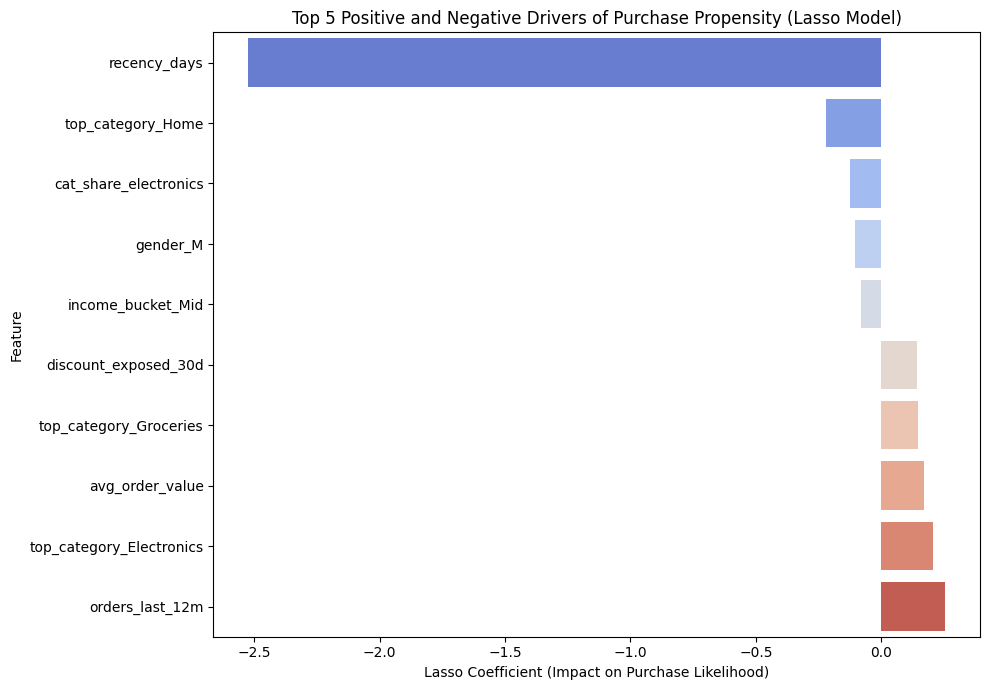

In [57]:
# Combine positive and negative drivers
drivers_to_plot = pd.concat([top5_positive, top5_negative])

# Sort by coefficient for better visualization in bar chart
drivers_to_plot = drivers_to_plot.sort_values('coef', ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(x='coef', y='feature', data=drivers_to_plot, palette='coolwarm')
plt.title('Top 5 Positive and Negative Drivers of Purchase Propensity (Lasso Model)')
plt.xlabel('Lasso Coefficient (Impact on Purchase Likelihood)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The best Lasso model highlights recency, order frequency, average order value, discount exposure, website visits, and specific top categories (Electronics, Groceries, Home) as the strongest drivers of purchase propensity, while it effectively drops two weaker features, giving a sparse and interpretable set of levers for targeting